## Image registration

The notebook uses a python package itk-elastix (https://proceedings.scipy.org/articles/gerudo-f2bc6f59-00d) to demonstrate image registration in a few image examples. 

Source of the images:
The images are adapted from "Hautier, A., Mancini, G.-F., Müller, N., & Sordet-Dessimoz, J. (2024). Whole slide images of mouse liver serial sections - Test registration dataset [Dataset]. Zenodo. https://doi.org/10.5281/zenodo.12072433" licensed under CC BY 4.0. Sections 01 and 02 of the dataset were cropped to use as the test dataset.

In [148]:
import itk
import numpy as np
import matplotlib.pyplot as plt

### Reading the files

In [149]:
image_location= "C:/Users/sugsi131/Documents/GitHub/I2KWorkshop_2026/data/"
fixed_image = itk.imread(image_location+"Image_01.tif", itk.F)
moving_image = itk.imread(image_location+"Image_02.tif", itk.F)

### Visualization

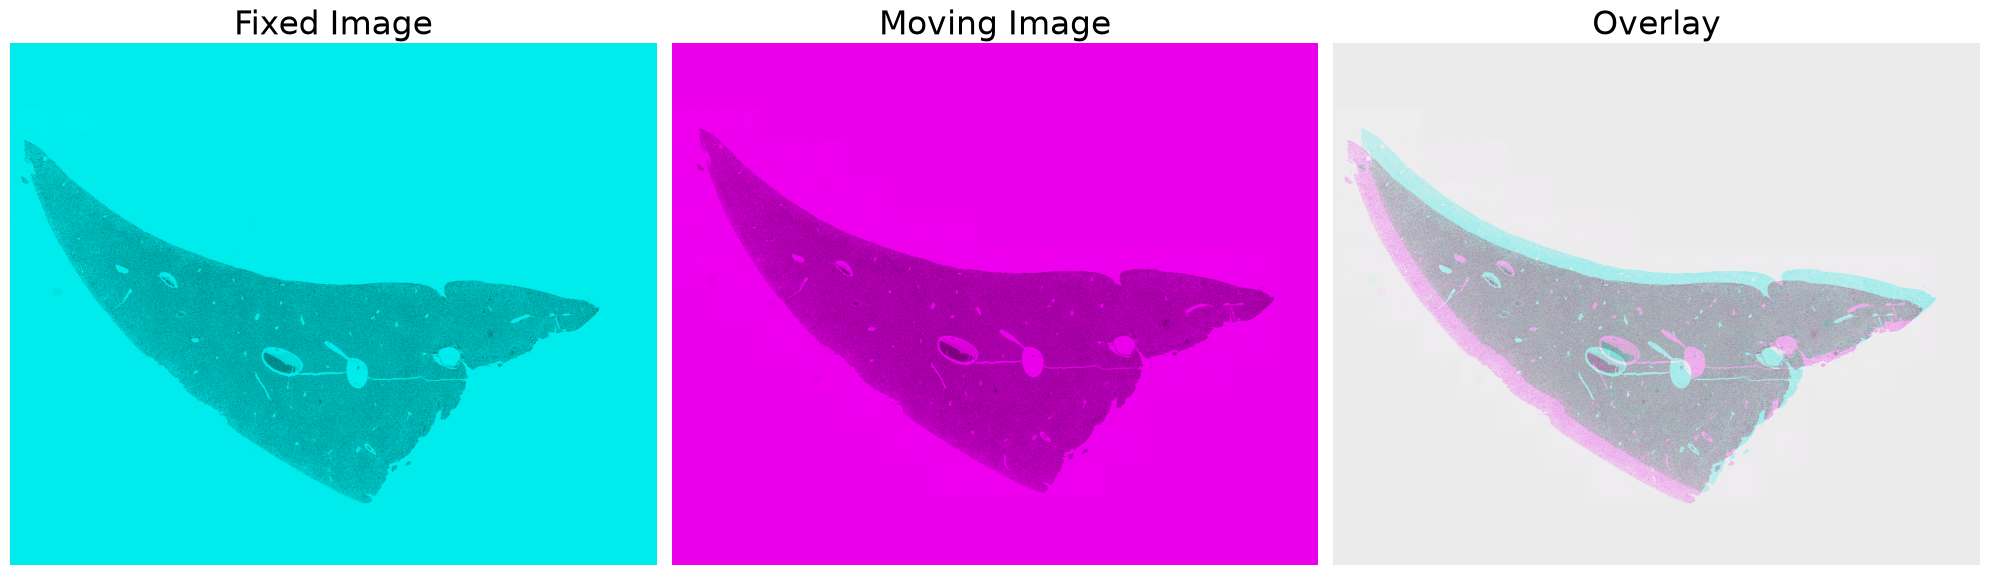

In [150]:

# Visualization
# Convert to array
fixed_arr = itk.GetArrayFromImage(fixed_image).astype(float)
moving_arr = itk.GetArrayFromImage(moving_image).astype(float)

fixed_slice = (fixed_arr - fixed_arr.min()) / (np.ptp(fixed_arr) + 1e-8)
moving_slice = (moving_arr - moving_arr.min()) / (np.ptp(moving_arr) + 1e-8)

fixed_color = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
fixed_color[:, :, 1] = fixed_slice
fixed_color[:, :, 2] = fixed_slice

moving_color = np.zeros((moving_slice.shape[0], moving_slice.shape[1], 3))
moving_color[:, :, 0] = moving_slice
moving_color[:, :, 2] = moving_slice

before_reg = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
before_reg[:, :, 0] = moving_slice
before_reg[:, :, 1] = fixed_slice
before_reg[:, :, 2] = np.maximum(fixed_slice, moving_slice)

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

axes[0].imshow(fixed_color)
axes[0].set_title('Fixed Image', fontsize=24)
axes[0].axis('off')

axes[1].imshow(moving_color)
axes[1].set_title('Moving Image', fontsize=24)
axes[1].axis('off')

axes[2].imshow(before_reg)
axes[2].set_title('Overlay', fontsize=24)
axes[2].axis('off')

plt.tight_layout()

### Registration 

In [151]:

default_rigid_parameter_map = itk.ParameterObject.GetDefaultParameterMap("rigid")
parameter_object = itk.ParameterObject.New(parameter_map=default_rigid_parameter_map)


In [152]:
# Call registration function
result_image, result_transform_parameters = itk.elastix_registration_method(
    fixed_image, moving_image, parameter_object=parameter_object, log_to_console=False
)

In [153]:
#Saving the registered image
itk.imwrite(result_image, image_location+"RegisteredLiverTissue.tif")

### Visualization

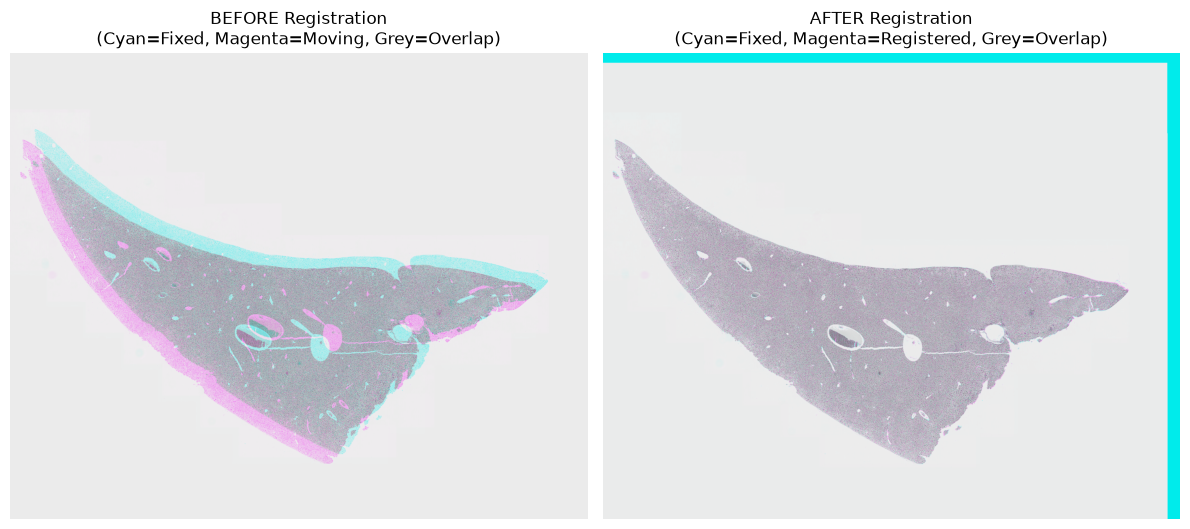

In [154]:

# Visualization
# Convert to array
fixed_arr = itk.GetArrayFromImage(fixed_image).astype(float)
moving_arr = itk.GetArrayFromImage(moving_image).astype(float)
registered_arr = itk.GetArrayFromImage(result_image).astype(float)


fixed_slice = (fixed_arr - fixed_arr.min()) / (np.ptp(fixed_arr) + 1e-8)
moving_slice = (moving_arr - moving_arr.min()) / (np.ptp(moving_arr) + 1e-8)
registered_slice = (registered_arr - registered_arr.min()) / (np.ptp(registered_arr) + 1e-8)

# Create BEFORE overlay (Fixed vs Moving)
overlay_before = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
overlay_before[:, :, 0] = moving_slice                          # Magenta = Moving
overlay_before[:, :, 1] = fixed_slice                            # Cyan = Fixed
overlay_before[:, :, 2] = np.maximum(fixed_slice, moving_slice)  # Greyscale = Overlap

# Create AFTER overlay (Fixed vs Registered)
overlay_after = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
overlay_after[:, :, 0] = registered_slice                          # Magenta = Registered
overlay_after[:, :, 1] = fixed_slice                               # Cyan = Fixed
overlay_after[:, :, 2] = np.maximum(fixed_slice, registered_slice) # Greyscale = Overlap

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(overlay_before)
axes[0].set_title('BEFORE Registration\n(Cyan=Fixed, Magenta=Moving, Grey=Overlap)')
axes[0].axis('off')

axes[1].imshow(overlay_after)
axes[1].set_title('AFTER Registration\n(Cyan=Fixed, Magenta=Registered, Grey=Overlap)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Registration quality: SSIM

The Structural Similarity Index (SSIM) compares local patterns of pixel intensities (luminance, contrast, structure) between two images instead of just their raw pixel-wise differences. It ranges from -1 to 1:

* **1** — the two images are identical
* **0** — no structural similarity
* **-1** — perfectly anti-correlated

Higher is better: an increase in SSIM after registration indicates the moving image has been better aligned to the fixed image.

### Registration quality: 

Structural similarity (SSIM) between fixed image and moving/registered image, before and after registration

In [155]:

from skimage.metrics import structural_similarity as ssim

ssim_before = ssim(fixed_slice, moving_slice, data_range=1.0)
ssim_after = ssim(fixed_slice, registered_slice, data_range=1.0)

print(f"SSIM before registration: {ssim_before:.4f}")
print(f"SSIM after registration:  {ssim_after:.4f}")

SSIM before registration: 0.7682
SSIM after registration:  0.7922


A default set of registration parameters are available for

* translation
* rigid
* affine
* bspline
* spline
* groupwise

### Understanding the parameters

In [156]:
# Get number of transforms (could be multiple for multi-resolution)
num_transforms = result_transform_parameters.GetNumberOfParameterMaps()
print(f"Number of parameter maps: {num_transforms}")

# Get the parameter map (usually index 0 for single transform)
param_map = result_transform_parameters.GetParameterMap(0)

# Print all parameters
print("All Parameters")
for key in param_map:
    print(f"{key}: {param_map[key]}")

Number of parameter maps: 1
All Parameters
CenterOfRotationPoint: ('1023.5', '826.5')
CompressResultImage: ('false',)
DefaultPixelValue: ('0',)
Direction: ('1', '0', '0', '1')
FinalBSplineInterpolationOrder: ('3',)
FixedImageDimension: ('2',)
FixedInternalImagePixelType: ('float',)
HowToCombineTransforms: ('Compose',)
Index: ('0', '0')
InitialTransformParameterFileName: ('NoInitialTransform',)
MovingImageDimension: ('2',)
MovingInternalImagePixelType: ('float',)
NumberOfParameters: ('3',)
Origin: ('0', '0')
ResampleInterpolator: ('FinalBSplineInterpolator',)
Resampler: ('DefaultResampler',)
ResultImageFormat: ('nii',)
ResultImagePixelType: ('float32',)
Size: ('2048', '1654')
Spacing: ('1', '1')
Transform: ('EulerTransform',)
TransformParameters: ('0.00011507461103149025', '44.43770453208737', '-35.89926597867684')
UseDirectionCosines: ('true',)


### Visualizing the transformation with a grid image

Applying the resulting transform parameters to a regular grid image makes the geometric effect of the registration (translation, rotation, shearing, scaling) much easier to see than comparing the photographic images alone.

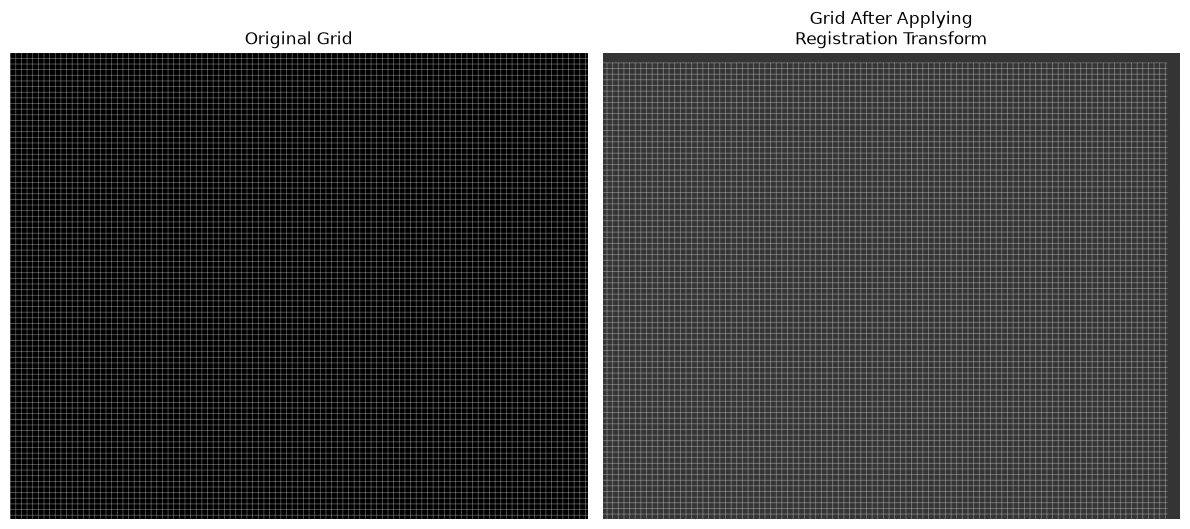

In [157]:
# Create a synthetic grid image in the moving image's space
grid_arr = np.zeros_like(moving_arr, dtype=np.float32)
grid_spacing = 20
grid_arr[::grid_spacing, :] = 1
grid_arr[:, ::grid_spacing] = 1

grid_image = itk.GetImageFromArray(grid_arr)
grid_image.CopyInformation(moving_image)

# Apply the transform found during registration to the grid image
transformed_grid = itk.transformix_filter(
    grid_image, transform_parameter_object=result_transform_parameters, log_to_console=False
)
transformed_grid_arr = itk.GetArrayFromImage(transformed_grid)

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(grid_arr, cmap='gray')
axes[0].set_title('Original Grid')
axes[0].axis('off')

axes[1].imshow(transformed_grid_arr, cmap='gray')
axes[1].set_title('Grid After Applying\nRegistration Transform')
axes[1].axis('off')

plt.tight_layout()
plt.show()